Predicted next 10 numbers: [50.8 51.8 52.8 53.9 54.9 56.  57.  58.4 59.7 61. ]


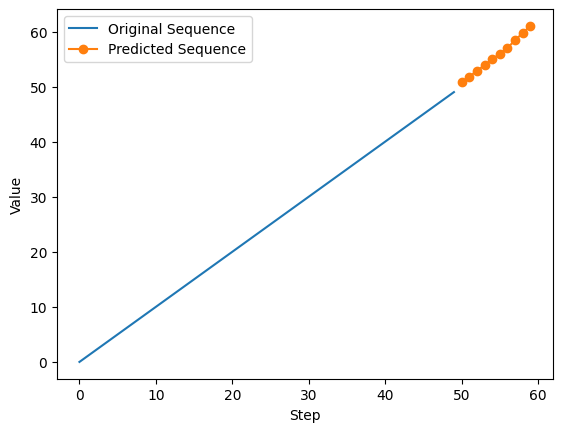

In [11]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
sequence = np.array([i for i in range(50)])
timesteps = 5  # طول توالی برای پیش‌بینی عدد بعدی
X, y = [], []
for i in range(len(sequence) - timesteps):
    X.append(sequence[i:i+timesteps])
    y.append(sequence[i+timesteps])
X = np.array(X)
y = np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))
model = keras.Sequential([
  layers.Input(shape=(timesteps, 1)),
layers.SimpleRNN(10, activation='relu'),
    layers.Dense(1)  
])
model.compile(optimizer='adam', loss='mse')  # MSE برای پیش‌بینی عددی
history = model.fit(X, y, epochs=200, verbose=0)
input_seq = sequence[-timesteps:].reshape((1, timesteps, 1))
predicted = []
for _ in range(10):  
    next_val = model.predict(input_seq, verbose=0)[0,0]
    predicted.append(next_val)
    input_seq = np.roll(input_seq, -1)
    input_seq[0, -1, 0] = next_val
print("Predicted next 10 numbers:", np.round(predicted, 1))
plt.plot(sequence, label='Original Sequence')
plt.plot(range(50, 60), predicted, label='Predicted Sequence', marker='o')
plt.xlabel('Step')
plt.ylabel('Value')
plt.legend()
plt.show()
